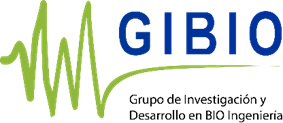


##**INVESTIGACIÓN EN INGENIERÍA CARDIOVASCULAR**

#**4. MODELOS CARDIOVASCULARES**


## ***RESUMEN***
A partir de la forma de onda de **Flujo Aórtico** obtenida *in vivo*, se diseñará e implementará un **Modelo Windkessel de Dos Elementos ($WK_2$)**. Se asignarán valores a la compliance arterial ($CA$) y a la resistencia periférica ($RP$) de modo de lograr un comportamiento dentro del rango fisiológico.  

1. Visualización de la **forma de onda de excitación** ($Q$)
2. Obtención de la **forma de onda de la respuesta** ($PA_O$) a partir de la resolución numérica de la **EDO WK2**
3. Cálculo de los **parámetros fisiológicos característicos** resultantes  

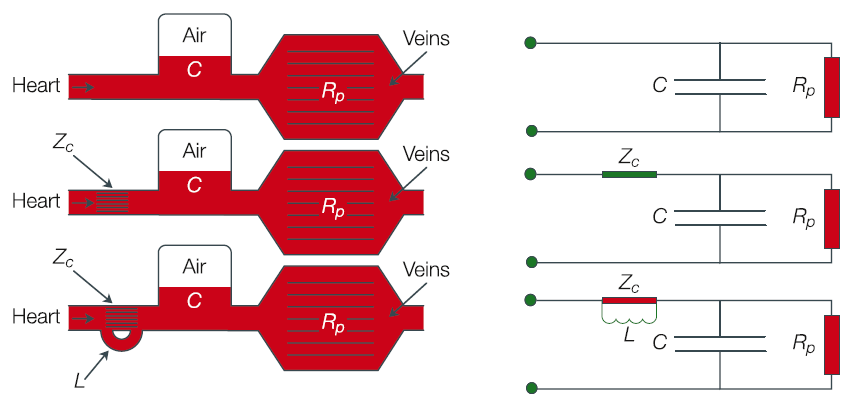

## **MÓDULOS DE USO GENERAL**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd

In [2]:
def Q_Sim(Qmax,T,t):
    """
    ===============================================================================
    Flujo_Sim: Generación de una señal de FLUJO (Semiseno) similar al humano [ml/s]
    Parámetros de entrada:
      -Qmax: Flujo Máximo
      -T: Duración de un período
      -t: Rango de evaluación
      ==============================================================================
    """
    Escala_ml=1e5*(Qmax/8.8) #Ajuste a (500 ml/s)
    Q = Escala_ml*((7.9853e-06+2.6617e-05*np.sin(2*np.pi*t/T+0.29498)+2.3616e-05*np.sin(4*np.pi*t/T-1.1403)-1.9016e-05*np.sin(6*np.pi*t/T+0.40435)-8.5899e-06*np.sin(8*np.pi*t/T-1.1892)-2.436e-06*np.sin(10*np.pi*t/T-1.4918)+1.4905e-06*np.sin(12*np.pi*t/T+1.0536)+1.3581e-06*np.sin(14*np.pi*t/T-0.47666)-6.3031e-07*np.sin(16*np.pi*t/T+0.93768)-4.5335e-07*np.sin(18*np.pi*t/T-0.79472)-4.5184e-07*np.sin(20*np.pi*t/T-1.4095)-5.6583e-07*np.sin(22*np.pi*t/T-1.3629)+4.9522e-07*np.sin(24*np.pi*t/T+0.52495)+1.3049e-07*np.sin(26*np.pi*t/T-0.97261)-4.1072e-08*np.sin(28*np.pi*t/T-0.15685)-2.4182e-07*np.sin(30*np.pi*t/T-1.4052)-6.6217e-08*np.sin(32*np.pi*t/T-1.3785)-1.5511e-07*np.sin(34*np.pi*t/T-1.2927)+2.2149e-07*np.sin(36*np.pi*t/T+0.68178)+6.7621e-08*np.sin(38*np.pi*t/T-0.98825)+1.0973e-07*np.sin(40*np.pi*t/T+1.4327)-2.5559e-08*np.sin(42*np.pi*t/T-1.2372)-3.5079e-08*np.sin(44*np.pi*t/T+0.2328)));
    return Q


## **LECTURA DE SEÑALES ADQUIRIDAS**

####**2.1 IMPLEMENTACIÓN DEL MODELO**

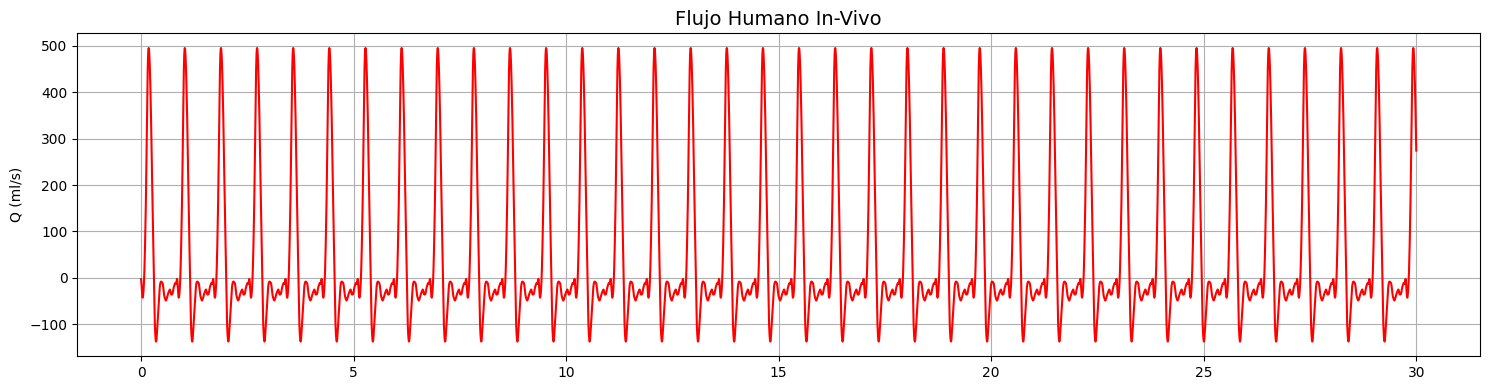

In [3]:
#FLUJO DE INGRESO AL SISTEMA
Ts=0.001
t = np.arange(0, 30, Ts)
T0=0.85   #Duración del Latido
Qmax=500  #Flujo Máximo [ml/s]

#Viusualización
plt.figure(figsize=(15, 4))
plt.plot(t, Q_Sim(Qmax,T0,t), 'r')
plt.grid(True)
plt.ylabel('Q (ml/s)')
plt.title('Flujo Humano In-Vivo', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
#FUNCIÓN QUE DEFINE LA EDO DEL WK2
def EDO_WK2(PAO, t):
    """
    Ecuación Diferencial que modela el WK2
    P'+P/RpCa=Q/Ca
    """
    dPAO_dt = -(PAO/(RP*CA)) + (Q_Sim(Qmax,T0,t)/CA)
    return dPAO_dt

In [5]:
#RESOLUCIÓN DE LA EDO
#Parámetros del sistema
#Resistencia Periférica RP [mmHg.s/ml]
RP = 2.15
#Compliance Arterial CA [ml/mmHg]
CA = 1.4
#Condición inicial
PAO0 = 0
#Resolución utilizando odeint
PAO=sp.integrate.odeint(EDO_WK2,PAO0,t)

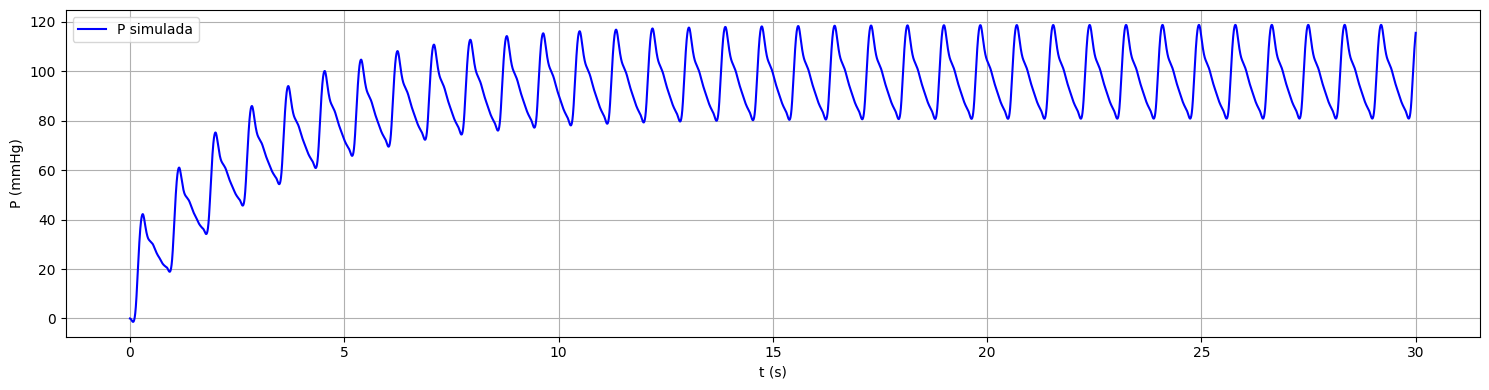

In [6]:
#RESULTADOS OBTENIDOS
plt.figure(figsize=(15, 4))

# Presión medida y simulada
plt.plot(t, PAO, 'b', label='P simulada')
plt.grid(True)
plt.legend()
plt.xlabel('t (s)')
plt.ylabel('P (mmHg)')

plt.tight_layout()
plt.show()

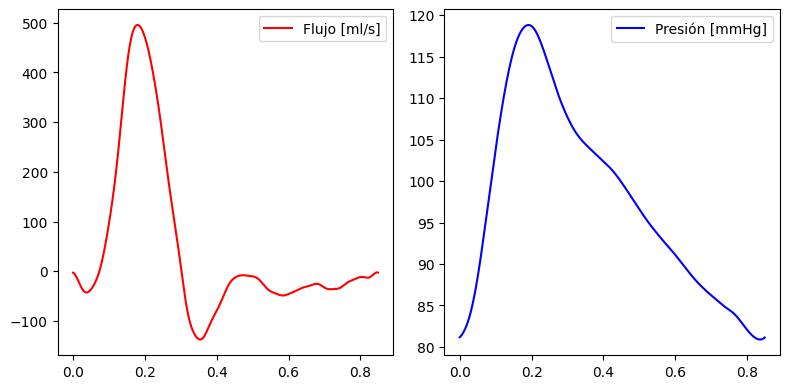

In [7]:
#Cálculo de los parámetros fisiológicos (1 Latido)
#Intervalo 1 latido
tini=29000
tfin=29850
t=np.arange(0,(tfin-tini)*Ts,Ts)
#Selección de último latido (estable)
Q_lat=Q_Sim(Qmax,T0,t)
P_lat=PAO[tini:tfin]

#Visualización Latido
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(t,Q_lat,'r',label='Flujo [ml/s]')
plt.legend()
plt.subplot(1,2,2)
plt.plot(t,P_lat,'b',label='Presión [mmHg]')
plt.legend()
plt.tight_layout()

In [8]:
#Frecuencia Cardíaca [lat/s]
FC=1/T0
#Pico de Flujo Aórtico [ml/s]
PFA=np.max(Q_lat)
#Volumen de Eyección [ml] (VE=Área sistólica de Q (aprox. 1/3 del latido))
VE=np.trapezoid(Q_lat[0:int(len(t)/2.8)])*Ts
#Gasto Cardíaco [ml/s] (GC=VE*FC)
GC=VE*FC
#Presión Arterial media [mmHg] (PAM=(Área de la PA)/T)
PAM=(np.trapezoid(P_lat[:,0])*Ts)/T0
#Presión Pulsátil [mmHg] (PP=PAmax-PAmin)
PP=np.max(P_lat)-np.min(P_lat)
#Resistencia Periférica Estimada (RPe=PAM/GC)
RPe=PAM/GC
#Compliance Arterial Estimada (CAe=VE/PP)
CAe=VE/PP

In [9]:
#Generación de un Dataframe con los datos del modelo
windkessel_data = {
    "Parámetetro": [
        "Frecuencia Cardíaca",
        "Resistencia Periférica (RP_WK)",
        "Campliance Arterial (CA_WK)",
        "Pico de Flujo Aórtico",
        "Gasto Cardíaco (GC)",
        "Presión Arterial media (PAM)",
        "Presión Pulsátil (PP)",
        "Volumen de Eyección (VE)",
        "Resistencia Periférica Estimada (PAM/GC)",
        "Compliance Arterial Estimada (VE/PP)"
    ],
    "Valores Calculados": [
        FC,         # lat/s
        RP,         # mmHg·s/ml
        CA,         # ml/mmHg
        PFA,        # ml/s
        GC,         # ml/s
        PAM,        # mmHg
        PP,         # mmHg
        VE,         # ml
        RPe,        # mmHg·s/ml
        CAe         # ml/mmHg
    ],
    "Unidades": [
        "lat/s",
        "mmHg·s/ml",
        "ml/mmHg",
        "ml/s",
        "ml/s",
        "mmHg",
        "mmHg",
        "ml",
        "mmHg·s/ml",
        "ml/mmHg"
    ],
    "Valores Típicos en Humanos": [
        "1.2 lat/s (70 lat/min)",
        "1.20 mmHg.s/ml",
        "1.75 ml/mmHg",
        "500ml/s",
        "83.3 ml/s (5 L/min)",
        "100 mmHg",
        "40 mmHg",
        "70ml",
        "-",
        "-"
    ]
}
#Crear el DataFrame de Resultados
df_windkessel = pd.DataFrame(windkessel_data).round(1)
#Mostrar el DataFrame de Resultados
df_windkessel

,Parámetetro,Valores Calculados,Unidades,Valores Típicos en Humanos
0,Frecuencia Cardíaca,1.2,lat/s,1.2 lat/s (70 lat/min)
1,Resistencia Periférica (RP_WK),2.2,mmHg·s/ml,1.20 mmHg.s/ml
2,Campliance Arterial (CA_WK),1.4,ml/mmHg,1.75 ml/mmHg
3,Pico de Flujo Aórtico,495.4,ml/s,500ml/s
4,Gasto Cardíaco (GC),72.0,ml/s,83.3 ml/s (5 L/min)
5,Presión Arterial media (PAM),97.4,mmHg,100 mmHg
6,Presión Pulsátil (PP),37.9,mmHg,40 mmHg
7,Volumen de Eyección (VE),61.2,ml,70ml
8,Resistencia Periférica Estimada (PAM/GC),1.4,mmHg·s/ml,-
9,Compliance Arterial Estimada (VE/PP),1.6,ml/mmHg,-
